Predicting High-Performance Marketing Campaigns and Optimizing Budget Allocation Using Distributed ML

structured dataset

# Phase 2

In [0]:
# Imports
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from functools import reduce
import re

## 1) Paths (raw files)

In [0]:
paths = {
    "nykaa":   "/Volumes/workspace/default/final_project/nykaa_campaign_data.csv",
    "purplle": "/Volumes/workspace/default/final_project/purplle_campaign_data.csv",
    "tira":    "/Volumes/workspace/default/final_project/tira_campaign_data.csv"
}

# silver path and gold path
silver_path = "/Volumes/workspace/default/final_project/marketing_silver_parquet"
gold_path   = "/Volumes/workspace/default/final_project/marketing_gold_parquet"

## 2) Helper functions

In [0]:
def align_cols(df, all_cols):
    for c in all_cols:
        if c not in df.columns:
            df = df.withColumn(c, F.lit(None))
    return df.select(all_cols)

# Normalize column names: lowercase, replace non-alphanumerics with underscore
def normalize_colname(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c


def read_campaign(path: str, brand: str):
    # Read raw CSV and standardize schema
    df = (spark.read
          .option("header", True)
          .option("inferSchema", True)
          .csv(path))

    # Normalize column names
    for old in df.columns:
        df = df.withColumnRenamed(old, normalize_colname(old))

    # Add brand_source column
    df = df.withColumn("brand_source", F.lit(brand))
    return df


# safe_div => to avoid division-by-zero (returns null if denominator <= 0 or null)
def safe_div(num_col, den_col):
    return F.when((den_col.isNotNull()) & (den_col > 0) & (num_col.isNotNull()), num_col / den_col)

## 3) Ingest + Union all sources

In [0]:
dfs = [read_campaign(p, b) for b, p in paths.items()]
all_cols = sorted(set().union(*[set(d.columns) for d in dfs]))

dfs_aligned = [align_cols(d, all_cols) for d in dfs]
df_all = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs_aligned)

# Drop duplicates (exactly same rows)
df_all = df_all.dropDuplicates()

df_all.printSchema()

root
 |-- acquisition_cost: double (nullable = true)
 |-- brand_source: string (nullable = false)
 |-- campaign_id: string (nullable = true)
 |-- campaign_type: string (nullable = true)
 |-- channel_used: string (nullable = true)
 |-- clicks: integer (nullable = true)
 |-- conversions: integer (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- date: date (nullable = true)
 |-- duration: integer (nullable = true)
 |-- engagement_score: double (nullable = true)
 |-- impressions: integer (nullable = true)
 |-- language: string (nullable = true)
 |-- leads: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- roi: double (nullable = true)
 |-- target_audience: string (nullable = true)



## 4) Basic cleaning
strings + sanity check

In [0]:
# Identify string columns
string_cols = [c for c, t in df_all.dtypes if t == "string"]

# Fill nulls in string cols as "Unknown"
df_all = df_all.fillna({c: "Unknown" for c in string_cols})

# Trim whitespace in string cols
for c in string_cols:
    df_all = df_all.withColumn(c, F.trim(F.col(c)))

# Quick sanity check for negative values
nonneg_cols = [c for c, t in df_all.dtypes if t in ("int", "bigint", "double", "float") and c not in ("roi",)]
for c in nonneg_cols:
    df_all = df_all.withColumn(
        c,
        F.when(F.col(c) < 0, None).otherwise(F.col(c))
    )

## 5) Feature engineering
### KPI + Funnel metrics

In [0]:
df_feat = (df_all
    .withColumn("ctr", safe_div(F.col("clicks"), F.col("impressions")))              # clicks / impressions
    .withColumn("lead_rate", safe_div(F.col("leads"), F.col("clicks")))              # leads / clicks
    .withColumn("lead_to_conv", safe_div(F.col("conversions"), F.col("leads")))      # conversions / leads
    .withColumn("click_to_conv", safe_div(F.col("conversions"), F.col("clicks")))    # conversions / clicks (overall)
    .withColumn("cpc", safe_div(F.col("acquisition_cost"), F.col("clicks")))         # cost / clicks
    .withColumn("cpa", safe_div(F.col("acquisition_cost"), F.col("conversions")))    # cost / conversions
    .withColumn("roas", safe_div(F.col("revenue"), F.col("acquisition_cost")))       # revenue / cost
    .withColumn("rpm", safe_div(F.col("revenue").cast("double") * 1000, F.col("impressions"))) # revenue per 1000 impressions
)


# (for safety) Keep ratio metrics within [0, 1] where applicable (funnel rates)
df_feat = (df_feat
    .withColumn("ctr", F.when((F.col("ctr") < 0) | (F.col("ctr") > 1), None).otherwise(F.col("ctr")))
    .withColumn("lead_rate", F.when((F.col("lead_rate") < 0) | (F.col("lead_rate") > 1), None).otherwise(F.col("lead_rate")))
    .withColumn("lead_to_conv", F.when((F.col("lead_to_conv") < 0) | (F.col("lead_to_conv") > 1), None).otherwise(F.col("lead_to_conv")))
    .withColumn("click_to_conv", F.when((F.col("click_to_conv") < 0) | (F.col("click_to_conv") > 1), None).otherwise(F.col("click_to_conv")))
)

# display
display(
    df_feat.select(
        "brand_source", "impressions", "clicks", "leads", "conversions",
        "ctr", "lead_rate", "lead_to_conv", "click_to_conv", "cpc", "cpa", "roas"
    ).limit(20)
)

brand_source,impressions,clicks,leads,conversions,ctr,lead_rate,lead_to_conv,click_to_conv,cpc,cpa,roas
nykaa,77708,4985,1363,916,0.06415040922427549,0.27342026078234705,0.6720469552457814,0.18375125376128384,0.0241444332998997,0.13139737991266376,5251.246261216351
nykaa,29199,1719,704,274,0.05887187917394431,0.40954043048283884,0.38920454545454547,0.15939499709133217,0.42297265852239674,2.6536131386861315,140.1862217882243
nykaa,59910,3712,1431,951,0.061959606075780334,0.3855064655172414,0.6645702306079665,0.2561961206896552,0.08182381465517242,0.3193796004206099,1408.9816613439568
nykaa,29278,3293,1504,1073,0.11247352961267847,0.45672638931065895,0.7134308510638298,0.3258426966292135,0.07729122380807775,0.23720410065237651,2816.140185447116
nykaa,59293,3248,1030,375,0.05477881031487697,0.3171182266009852,0.3640776699029126,0.11545566502463055,0.16726908866995072,1.4487733333333332,293.35161700012884
nykaa,47178,5999,1619,787,0.12715672559243715,0.26987831305217536,0.48610253242742435,0.13118853142190365,0.01804634105684281,0.13756035578144854,1926.4271198965453
nykaa,82471,5797,3251,1940,0.07029137515005275,0.5608073141279972,0.5967394647800677,0.33465585647748836,0.017531481800931517,0.052386597938144326,13476.729312210962
nykaa,58685,7497,3204,1036,0.12774985089886684,0.42737094837935174,0.3233458177278402,0.13818860877684408,0.02283580098706149,0.16525096525096525,2245.070093457944
nykaa,92447,4234,1240,974,0.04579921468517096,0.29286726499763815,0.785483870967742,0.2300425129900803,0.06380255077940482,0.2773511293634497,1182.6164211149776
nykaa,20630,2351,767,456,0.11396025206010664,0.3262441514249256,0.5945241199478487,0.1939600170140366,0.1011612079965972,0.5215570175438596,644.2248665012823


## 6) Save Silver layer
The Silver layer contains cleaned and feature-engineered campaign data.
At this stage, the raw campaign datasets from multiple brands are merged, basic cleaning is applied (null handling, trimming, sanity checks), and marketing KPIs and funnel metrics are created (CTR, CPC, CPA, ROAS, etc.).
This represents row-level campaign performance and serves as the foundation for further analysis and modeling.

In [0]:
# Save engineered row-level dataset as Silver
(df_feat
 .write
 .mode("overwrite")
 .parquet(silver_path))

# Reload Silver and register a temp view
df_silver = spark.read.parquet(silver_path)
df_silver.createOrReplaceTempView("marketing_silver")

# schema check
df_silver.printSchema()
display(df_silver.limit(5))

root
 |-- acquisition_cost: double (nullable = true)
 |-- brand_source: string (nullable = true)
 |-- campaign_id: string (nullable = true)
 |-- campaign_type: string (nullable = true)
 |-- channel_used: string (nullable = true)
 |-- clicks: integer (nullable = true)
 |-- conversions: integer (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- date: date (nullable = true)
 |-- duration: integer (nullable = true)
 |-- engagement_score: double (nullable = true)
 |-- impressions: integer (nullable = true)
 |-- language: string (nullable = true)
 |-- leads: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- roi: double (nullable = true)
 |-- target_audience: string (nullable = true)
 |-- ctr: double (nullable = true)
 |-- lead_rate: double (nullable = true)
 |-- lead_to_conv: double (nullable = true)
 |-- click_to_conv: double (nullable = true)
 |-- cpc: double (nullable = true)
 |-- cpa: double (nullable = true)
 |-- roas: double (nullable = true)
 |

acquisition_cost,brand_source,campaign_id,campaign_type,channel_used,clicks,conversions,customer_segment,date,duration,engagement_score,impressions,language,leads,revenue,roi,target_audience,ctr,lead_rate,lead_to_conv,click_to_conv,cpc,cpa,roas,rpm
147.29,nykaa,NY-CMP-1007,Social Media,"Instagram, WhatsApp, Google",2665,925,Tier 2 City Customers,2025-05-31,6,15.63,32482,Hindi,1488,326525,1.4,Working Women,0.08204544055169016,0.5583489681050656,0.6216397849462365,0.34709193245778613,0.05526829268292682,0.15923243243243243,2216.8850566908823,10052.490610184102
1648.61,nykaa,NY-CMP-1015,Paid Ads,"Facebook, Instagram, Email",1511,158,Premium Shoppers,2024-10-06,23,7.35,28714,Hindi,441,33654,-0.87,Working Women,0.05262241415337466,0.29185969556585045,0.35827664399092973,0.10456651224354732,1.0910721376571806,10.434240506329113,20.413560514615344,1172.0415128508741
1124.19,nykaa,NY-CMP-1020,Paid Ads,"Google, YouTube",1217,163,Youth,2024-08-27,27,17.83,10678,Bengali,524,111981,-0.39,Premium Shoppers,0.11397265405506649,0.4305669679539852,0.3110687022900763,0.13393590797041907,0.9237387017255547,6.896871165644172,99.61038614469084,10487.076231504027
27.28,nykaa,NY-CMP-1030,SEO,YouTube,9525,2242,Youth,2025-03-17,18,17.33,92924,English,4340,652422,9.67,College Students,0.10250312082992553,0.45564304461942257,0.5165898617511521,0.23538057742782154,0.0028640419947506563,0.01216770740410348,23915.762463343108,7021.027936808575
231.17,nykaa,NY-CMP-1032,Social Media,"Instagram, WhatsApp, Facebook",6488,1181,Premium Shoppers,2025-05-09,17,13.21,72628,Tamil,1923,243286,-0.11,Premium Shoppers,0.08933193809550036,0.2963933415536375,0.6141445657826313,0.18202836004932182,0.03563039457459926,0.19574089754445384,1052.4116451096595,3349.754915459602


# Phase 3

## 1) Summary statistics

In [0]:
display(df_silver.summary())

summary,acquisition_cost,brand_source,campaign_id,campaign_type,channel_used,clicks,conversions,customer_segment,duration,engagement_score,impressions,language,leads,revenue,roi,target_audience,ctr,lead_rate,lead_to_conv,click_to_conv,cpc,cpa,roas,rpm
count,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665,166665
mean,376.094880928809,null,null,null,null,4682.367545675456,1029.088884888849,null,17.490366903669038,13.766293042930426,55060.8540905409,null,1871.5141811418114,513906.6154921549,2.6905667056670626,null,0.0850232706440739,0.39932129810708605,0.5496010037073958,0.21945369723635283,0.31953887643761913,2.0761873905857664,6439.071819279476,9331.382719739539
stddev,534.9395550288407,null,null,null,null,3176.5023398895014,858.0112175720758,null,7.504842827603848,6.330004792571446,25970.653993634398,null,1429.590998124685,487644.25174990855,4.481215897608889,null,0.037537840883735435,0.11544026886870597,0.14445007595913398,0.08732105887837185,1.2151142233010763,10.360204079618333,14464.670125439687,6939.71884911812
min,8.18,nykaa,NY-CMP-1000,Email,Email,202,17,College Students,5,2.56,10001,Bengali,48,3895,-0.99,College Students,0.01995920745920746,0.19799498746867167,0.288135593220339,0.05924170616113744,6.210670314637483E-4,0.0013296488946684005,0.25901050671631864,299.7289353702992
25%,106.73,null,null,null,null,2108,401,null,11,8.38,32564,null,779,177660,0.04,null,0.05255562236921227,0.29947089947089944,0.42424242424242425,0.15239829993928355,0.016915002186907713,0.07779205607476636,444.62699942970426,4221.629292081385
50%,208.49,null,null,null,null,3904,776,null,17,13.59,55102,null,1476,359192,1.23,null,0.08498779643728827,0.3989159891598916,0.5500588928150766,0.20504994450610434,0.05227970897332255,0.2641935483870968,1761.8738404452693,7458.091863430142
75%,427.46,null,null,null,null,6688,1404,null,24,18.79,77569,null,2598,684690,3.58,null,0.1177004803431335,0.4994608583135648,0.6744548286604362,0.2774712643678161,0.18920549288867092,1.0268311688311689,6114.130073739454,12516.019340098826
max,15473.16,tira,TI-CMP-9999,Social Media,"YouTube, WhatsApp, Instagram",14944,6686,Youth,30,30.99,100000,Tamil,8876,4579910,79.3,Youth,0.14999512528029638,0.599981144527199,0.7999314833847208,0.4786976099757534,59.51215384615384,870.73,504395.37444933923,51321.1026590191


In [0]:
spark.sql("""
SELECT
    COUNT(*) AS total_rows,
    AVG(clicks) AS avg_clicks,
    AVG(impressions) AS avg_impressions,
    AVG(conversions) AS avg_conversions,
    AVG(ctr) AS avg_ctr,
    AVG(roas) AS avg_roas
FROM marketing_silver
""").show()

+----------+-----------------+----------------+-----------------+-------------------+-----------------+
|total_rows|       avg_clicks| avg_impressions|  avg_conversions|            avg_ctr|         avg_roas|
+----------+-----------------+----------------+-----------------+-------------------+-----------------+
|    166665|4682.367545675456|55060.8540905409|1029.088884888849|0.08502327064407385|6439.071819279482|
+----------+-----------------+----------------+-----------------+-------------------+-----------------+



## 2) Feature Distributions

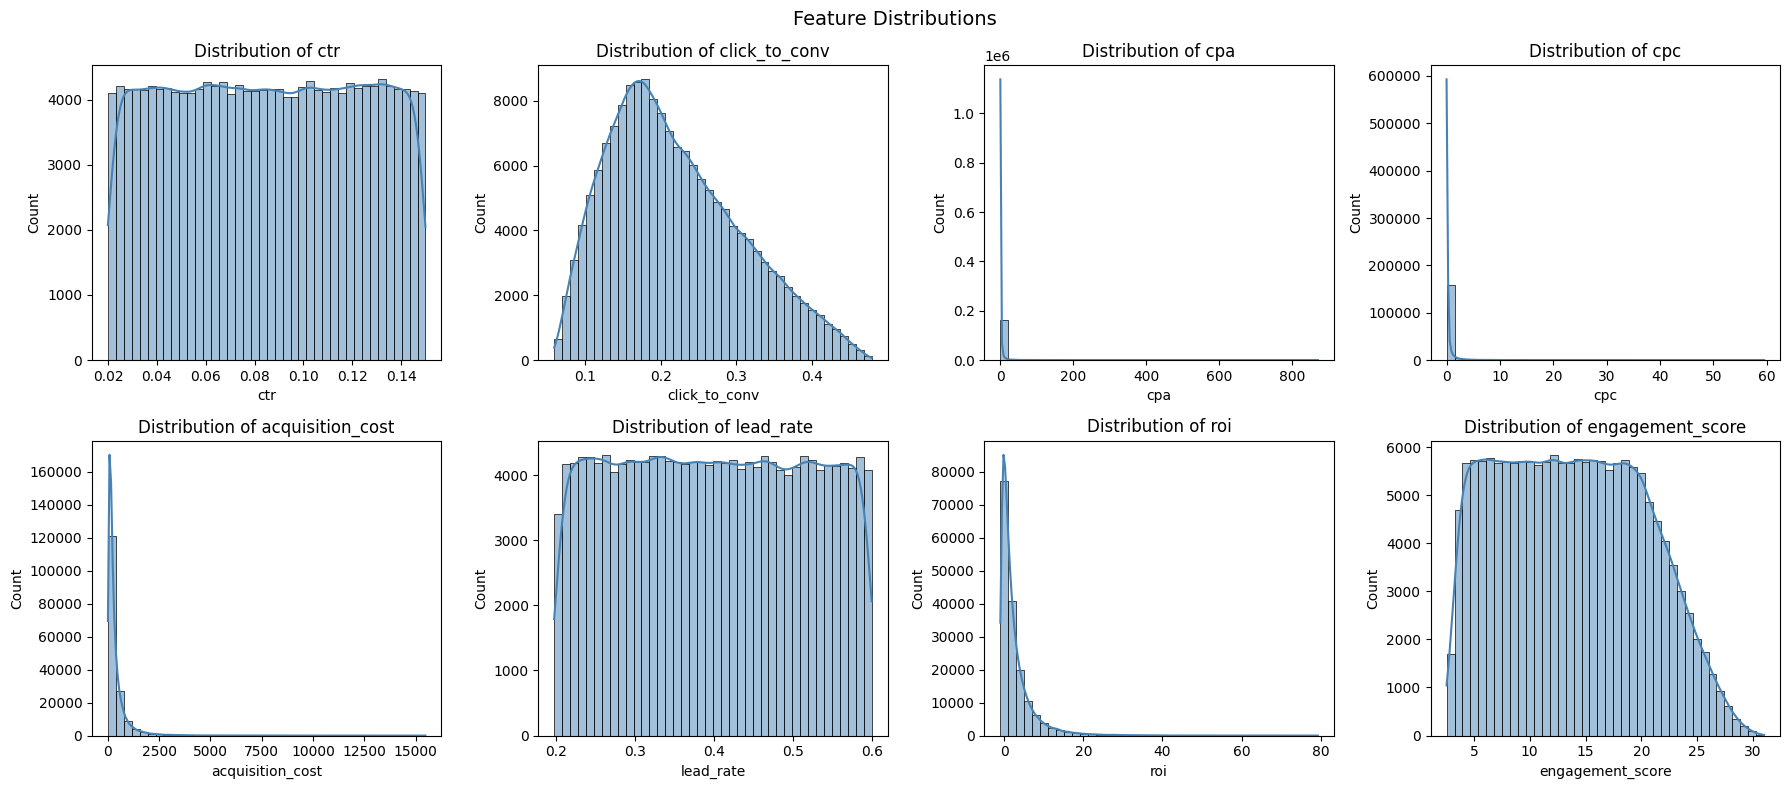

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect for visualization
pdf = (df_silver
    .select("ctr", "click_to_conv", "cpa", "cpc", "acquisition_cost", 
            "lead_rate", "roi", "engagement_score")
    .dropna()
    .toPandas()
)

# Distribution of each feature
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
features = ["ctr", "click_to_conv", "cpa", "cpc", 
            "acquisition_cost", "lead_rate", "roi", "engagement_score"]

for ax, col in zip(axes.flat, features):
    sns.histplot(pdf[col], kde=True, ax=ax, bins=40, color="steelblue")
    ax.set_title(f"Distribution of {col}")

plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## 3) Correlation Heatmap
Correlation matrix to detect multicollinearity

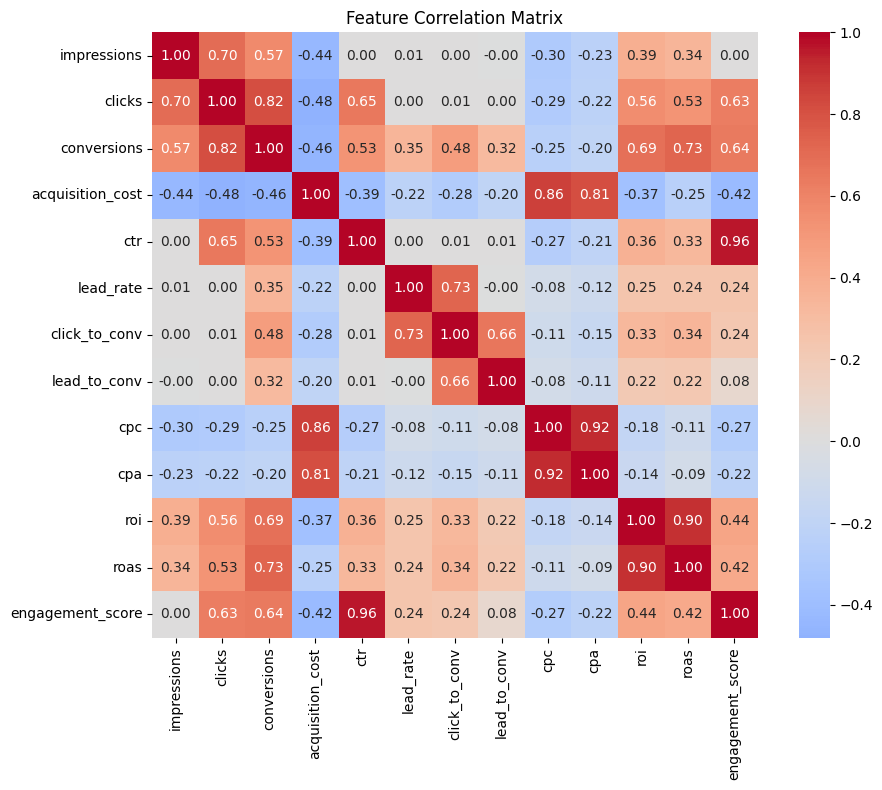

In [0]:
corr_cols = ["impressions", "clicks", "conversions", "acquisition_cost",
             "ctr", "lead_rate", "click_to_conv", "lead_to_conv",
             "cpc", "cpa", "roi", "roas", "engagement_score"]

corr_matrix = (df_silver
    .select(corr_cols)
    .dropna()
    .toPandas()
    .corr()
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 4) Monthly ROAS trend

In [0]:
# Check date range per brand
display(spark.sql("""
SELECT 
    brand_source,
    MIN(date) AS start_date,
    MAX(date) AS end_date,
    COUNT(*) AS n_campaigns
FROM marketing_silver
GROUP BY brand_source
ORDER BY brand_source
"""))

brand_source,start_date,end_date,n_campaigns
nykaa,2024-07-01,2025-06-24,55555
purplle,2024-07-01,2025-06-24,55555
tira,2024-07-01,2025-06-24,55555


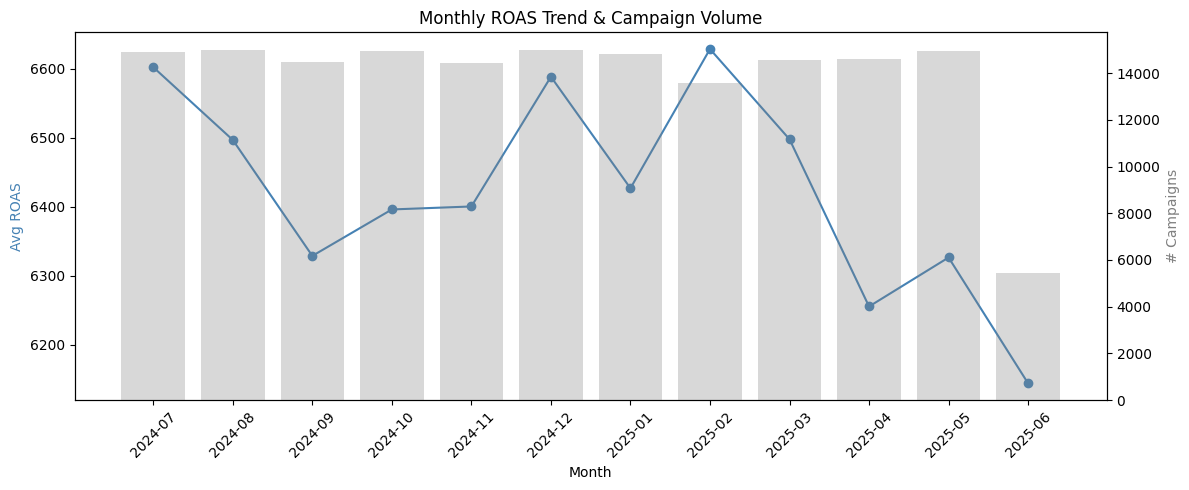

In [0]:
monthly_trend = spark.sql("""
SELECT
    DATE_FORMAT(to_date(date, 'dd-MM-yyyy'), 'yyyy-MM') AS month,
    ROUND(AVG(roas), 2)           AS avg_roas,
    ROUND(AVG(ctr), 4)           AS avg_ctr,
    COUNT(*)                     AS n_campaigns
FROM marketing_silver
GROUP BY DATE_FORMAT(to_date(date, 'dd-MM-yyyy'), 'yyyy-MM')
ORDER BY month
""").toPandas()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly_trend["month"], monthly_trend["avg_roas"], marker="o", color="steelblue", label="Avg ROAS")
ax1.set_xlabel("Month")
ax1.set_ylabel("Avg ROAS", color="steelblue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.bar(monthly_trend["month"], monthly_trend["n_campaigns"], alpha=0.3, color="gray", label="# Campaigns")
ax2.set_ylabel("# Campaigns", color="gray")

plt.title("Monthly ROAS Trend & Campaign Volume")
fig.tight_layout()
plt.show()

## 5) Performance by campaign type

In [0]:
display(spark.sql("""
SELECT
    campaign_type,
    COUNT(*) AS n_campaigns,
    ROUND(AVG(roas), 2)           AS avg_roas,
    ROUND(AVG(ctr), 4)           AS avg_ctr,
    ROUND(AVG(click_to_conv), 4) AS avg_conversion,
    ROUND(AVG(cpa), 2)           AS avg_cpa
FROM marketing_silver
GROUP BY campaign_type
ORDER BY avg_roas DESC
"""))

campaign_type,n_campaigns,avg_roas,avg_ctr,avg_conversion,avg_cpa
Social Media,33179,6532.04,0.0853,0.2187,2.05
Paid Ads,33283,6487.09,0.0851,0.2195,2.02
Email,33493,6479.48,0.0848,0.22,2.11
SEO,33207,6377.99,0.0847,0.22,2.09
Influencer,33503,6319.44,0.0853,0.2191,2.1


## 6) Channel explode

In [0]:
df_channel = (df_silver
    .withColumn("channel", F.explode(F.split(F.col("channel_used"), ",")))
    .withColumn("channel", F.trim(F.col("channel")))
)

display(
    df_channel.groupBy("channel")
    .agg(
        F.count("*").alias("n"),
        F.avg("roas").alias("avg_roas"),
        F.avg("ctr").alias("avg_ctr")
    )
    .orderBy(F.desc("avg_roas"))
)

channel,n,avg_roas,avg_ctr
Email,55590,6546.217093986786,0.08534084840969246
Instagram,55599,6491.002058688689,0.08525426841971195
Google,55576,6431.225260032147,0.08471593238756976
WhatsApp,55455,6410.382391929098,0.08519224773212922
Facebook,55578,6407.65506777866,0.08482686352767226
YouTube,55583,6387.456843429142,0.08478967830144529


## → Save Gold layer
The Gold layer is built on top of the Silver layer by adding the binary target 'label' based on the top 25% ROAS threshold identified during EDA. While the Silver layer serves as the foundation for exploratory analysis, the Gold layer is the final modeling-ready dataset. It contains all cleaned features, engineered KPIs, and the label column that the classifier will be trained to predict in Phase 4.

In [0]:
# Define target label: top 25% ROAS
# high performance (1), else (0)
q75 = df_silver.approxQuantile("roas", [0.75], 0.01)[0]

df_gold = df_silver.withColumn(
    "label",
    F.when(F.col("roas") >= q75, 1).otherwise(0)
)

(df_gold
 .write
 .mode("overwrite")
 .parquet(gold_path))

df_gold = spark.read.parquet(gold_path)
df_gold.createOrReplaceTempView("marketing_gold")

The target label is defined as 1 if a campaign's ROAS is in the top 25% of all campaigns, and 0 otherwise. 

This threshold was chosen because labeling only the top quartile as high-performing sets a meaningful and selective standard. It aligns with the project goal of identifying campaigns that generate strong revenue returns relative to advertising spend.

ROAS was selected as the primary performance metric because it directly measures the revenue generated per unit of advertising spend, making it a widely used indicator of marketing campaign effectiveness.